In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import codebase

In [2]:
fp = '/global/scratch/users/ann_scheliga/basin_forcing_processed/'
fn = '1834101_kainji.pkl'
full_fn = Path(fp)/Path(fn)

grdc_id = '1834101'
grdc_id = str(grdc_id)
dam_name = 'kainji'
dam_name = dam_name.replace(' ','_').lower()

save_fp = Path(fp) / Path('_'.join(['img_log',grdc_id,dam_name]))
save_fp.mkdir(exist_ok=True)

print('Save dir:',save_fp,flush=True)

Save dir: /global/scratch/users/ann_scheliga/basin_forcing_processed/img_log_1834101_kainji


In [3]:
full_dict = pd.read_pickle(full_fn)
full_df = full_dict[list(full_dict.keys())[0]]

In [4]:
full_df_decYear = full_df.copy()
full_df_decYear.index = full_df_decYear.index.map(codebase.time_series_calcs.toYearFraction)



In [5]:
precip_cols = full_df.columns[full_df.columns.str.contains('precip')]
tempK_cols = full_df.columns[full_df.columns.str.contains('tempK')]

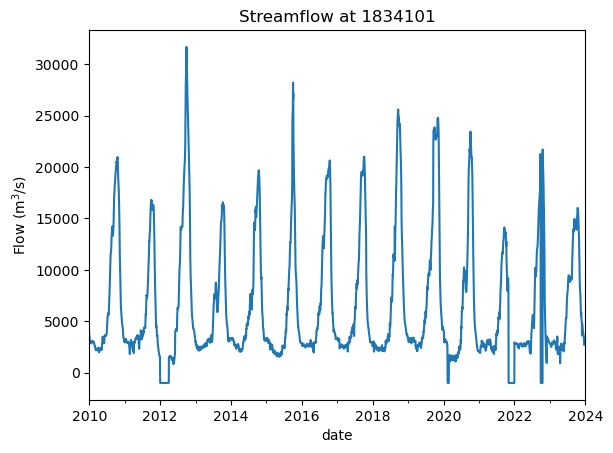

In [6]:
ax = full_df['Q'].plot()
ax.set_ylabel('Flow (m$^3$/s)')
ax.set_title(f'Streamflow at {grdc_id}')

output_name = f'flow_{grdc_id}.png'
plt.savefig(save_fp / output_name)
plt.show()

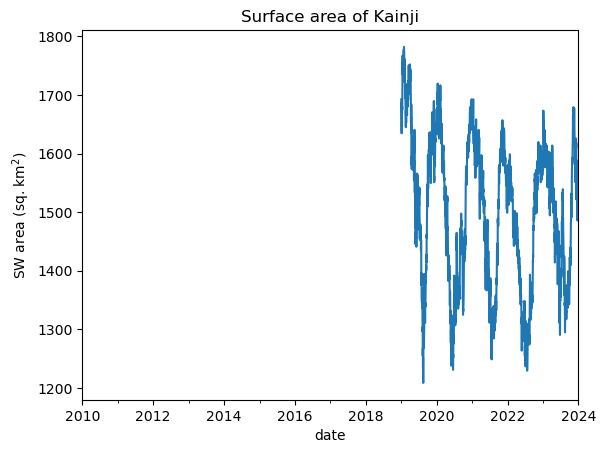

In [7]:
ax = full_df['SW_area'].plot()
ax.set_ylabel('SW area (sq. km$^2$)')
ax.set_title(f'Surface area of {dam_name.capitalize()}')

output_name = f'SWarea_{dam_name}_full.png'
plt.savefig(save_fp / output_name)
plt.show()

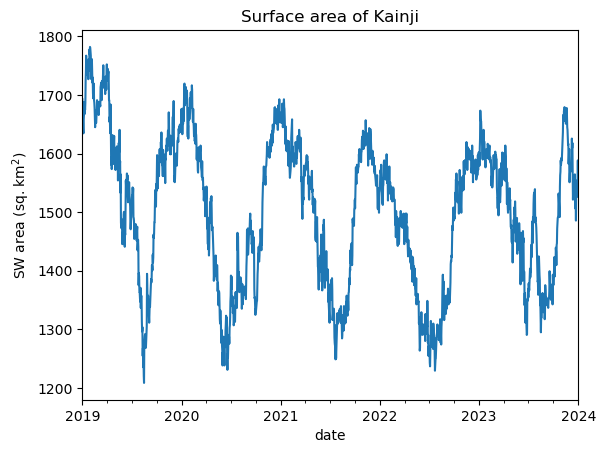

In [8]:
ax = full_df['SW_area'].dropna().plot()
ax.set_ylabel('SW area (sq. km$^2$)')
ax.set_title(f'Surface area of {dam_name.capitalize()}')

output_name = f'SWarea_{dam_name}_zoom.png'
plt.savefig(save_fp / output_name)
plt.show()

In [9]:
def plot_single_timeseries_with_colname(input_column):
    ax = input_column.plot()
    var_name = input_column.name
    ax.set_title(var_name)
    plt.show()

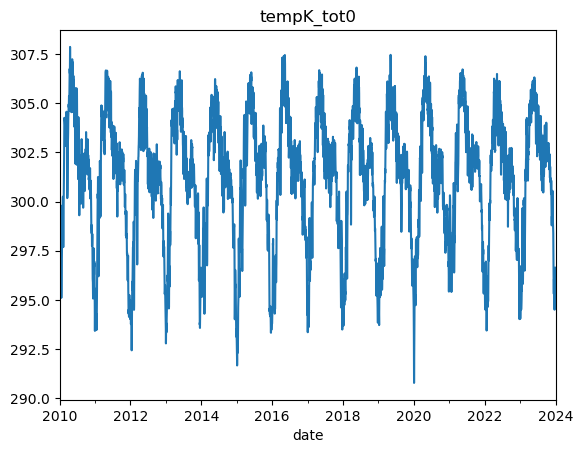

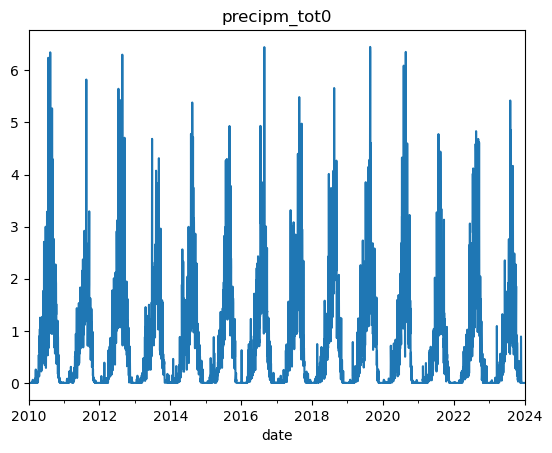

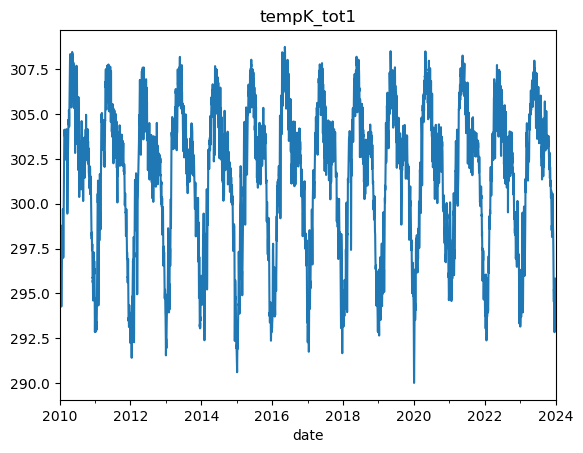

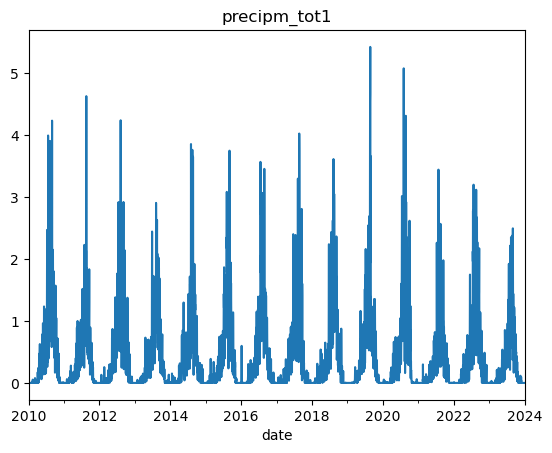

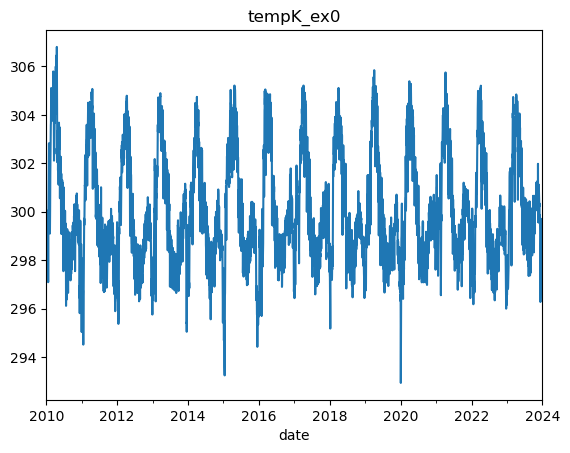

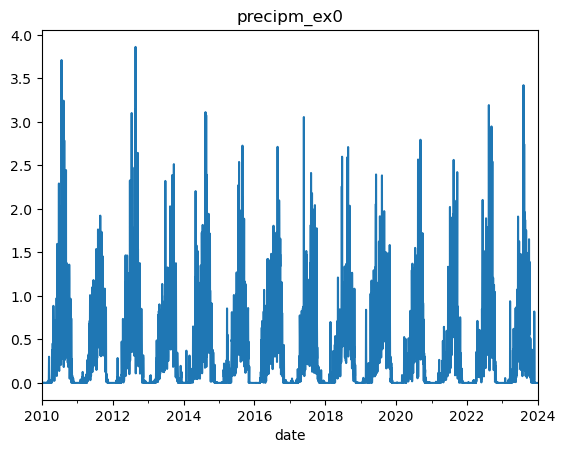

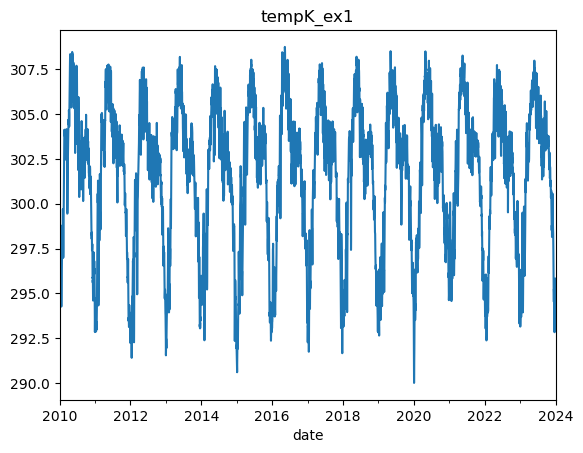

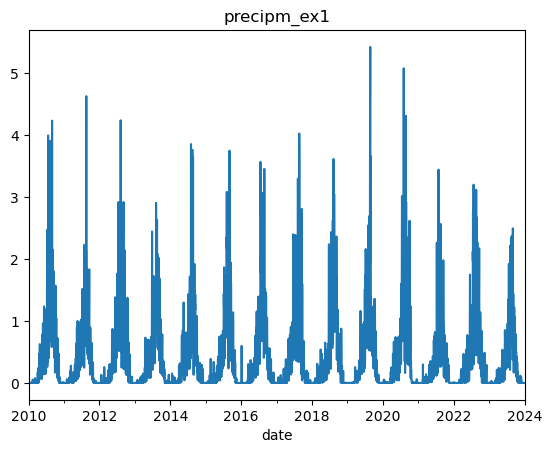

<Figure size 640x480 with 0 Axes>

In [14]:
for col in full_df.iloc[:,3:]:
    plot_single_timeseries_with_colname(full_df[col])
    output_name = f'{col}_ts.png'
    plt.savefig(save_fp / output_name)

In [11]:
input_df = full_df[precip_cols]
def calc_seasonality(input_df):
    daily_seasonality = input_df.groupby(input_df.index.day_of_year).mean()
    daily_seasonality_full_len = input_df.groupby(input_df.index.day_of_year).transform('mean')
    daily_detrend = input_df - daily_seasonality_full_len

    month_seasonality = input_df.groupby(input_df.index.month).mean()
    month_full_len = input_df.groupby(by = [input_df.index.year,input_df.index.month]).mean()
    month_seasonality_full_len = month_full_len.groupby(level=1).transform('mean')

    month_detrend = month_full_len - month_seasonality_full_len

    frame_date = month_detrend.index.to_frame(name=['year','month'])
    frame_date['day'] = 1
    month_detrend.index = pd.to_datetime(frame_date)

    fig ,axs = plt.subplots(figsize=(16,18))
    # axs.spines[:].set_visible(False)
    plt.axis('off')

    plt_kwargs = {'grid':'on'}
    ax1 = plt.subplot(3,2,1)
    daily_seasonality.plot(ax =ax1, **plt_kwargs, title='Daily seasonality')
    ax2 = plt.subplot(3,2,2)
    month_seasonality.plot(ax=ax2,**plt_kwargs, title='Monthly seasonality')
    ax3 = plt.subplot(3,1,2)
    daily_detrend.plot(ax=ax3,**plt_kwargs,legend=False, title='Anomalies')
    ax4 = plt.subplot(3,1,3)
    input_df.plot(ax=ax4,**plt_kwargs,legend=False,title='Full time series')




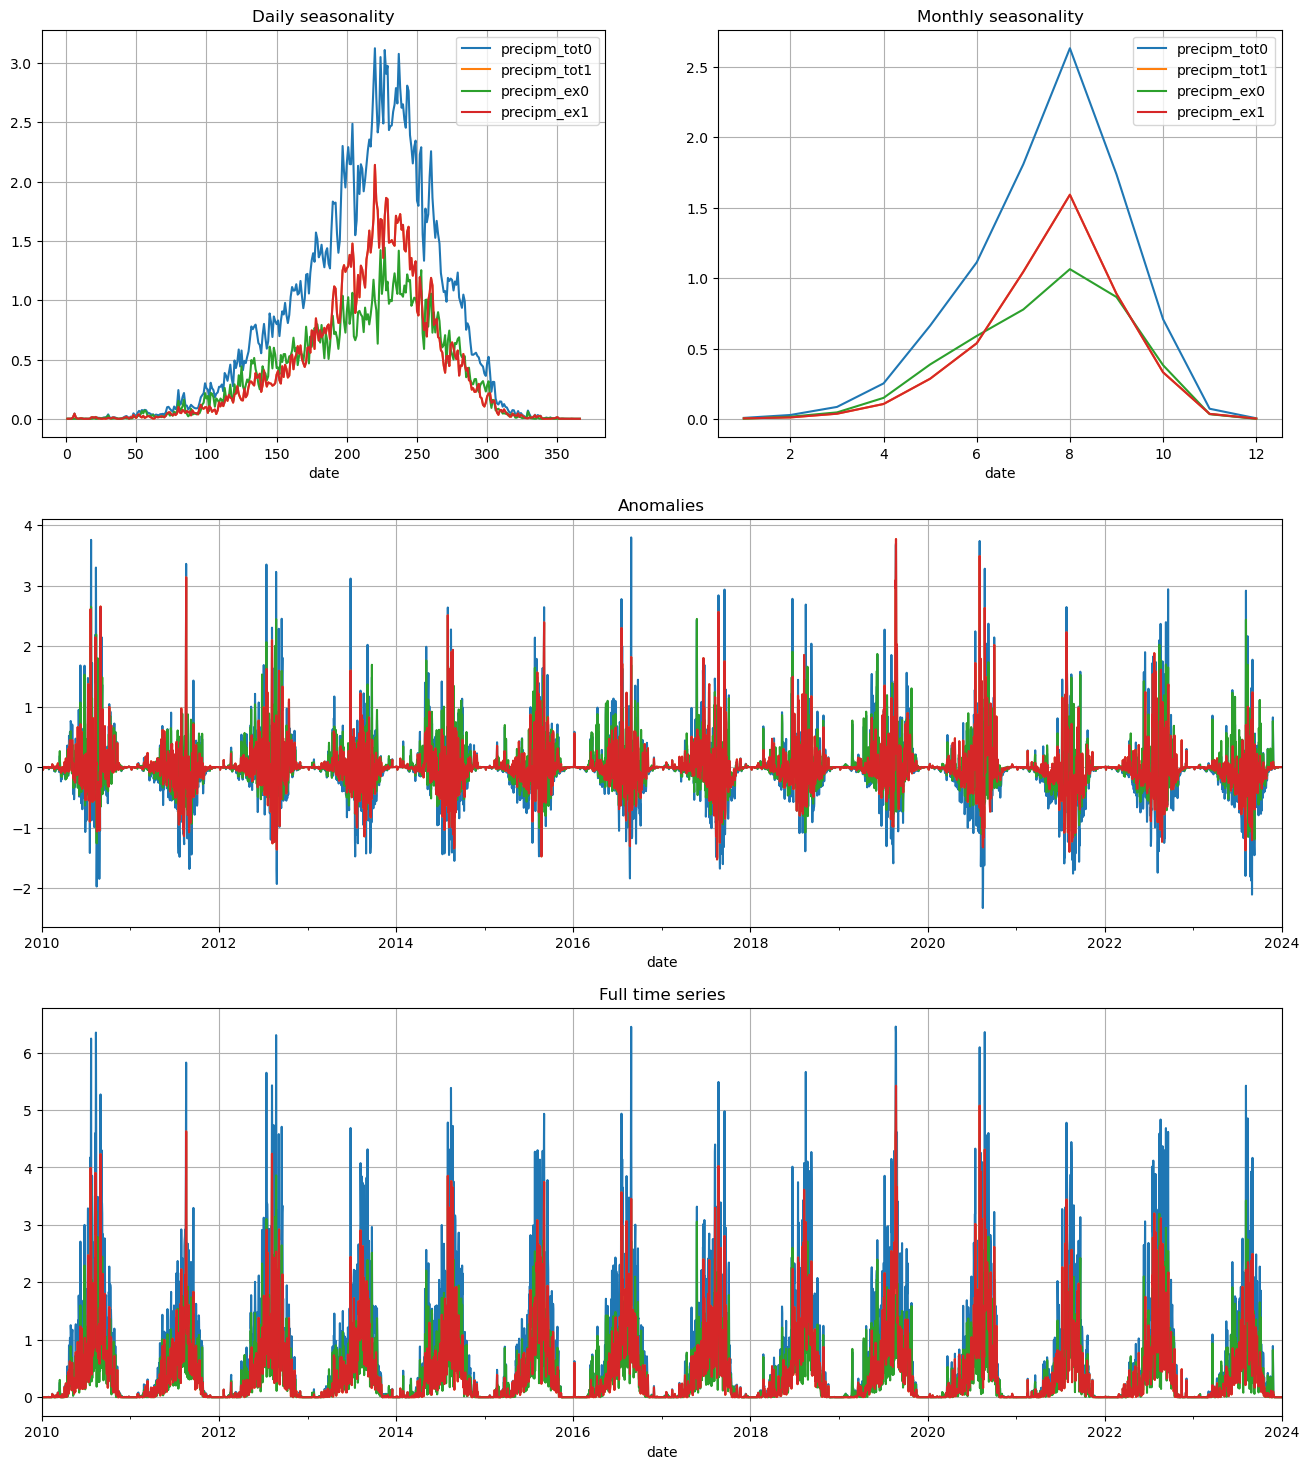

In [12]:
calc_seasonality(full_df[precip_cols])
output_name = f'precip_overlays.png'
plt.savefig(save_fp / output_name)
plt.show()

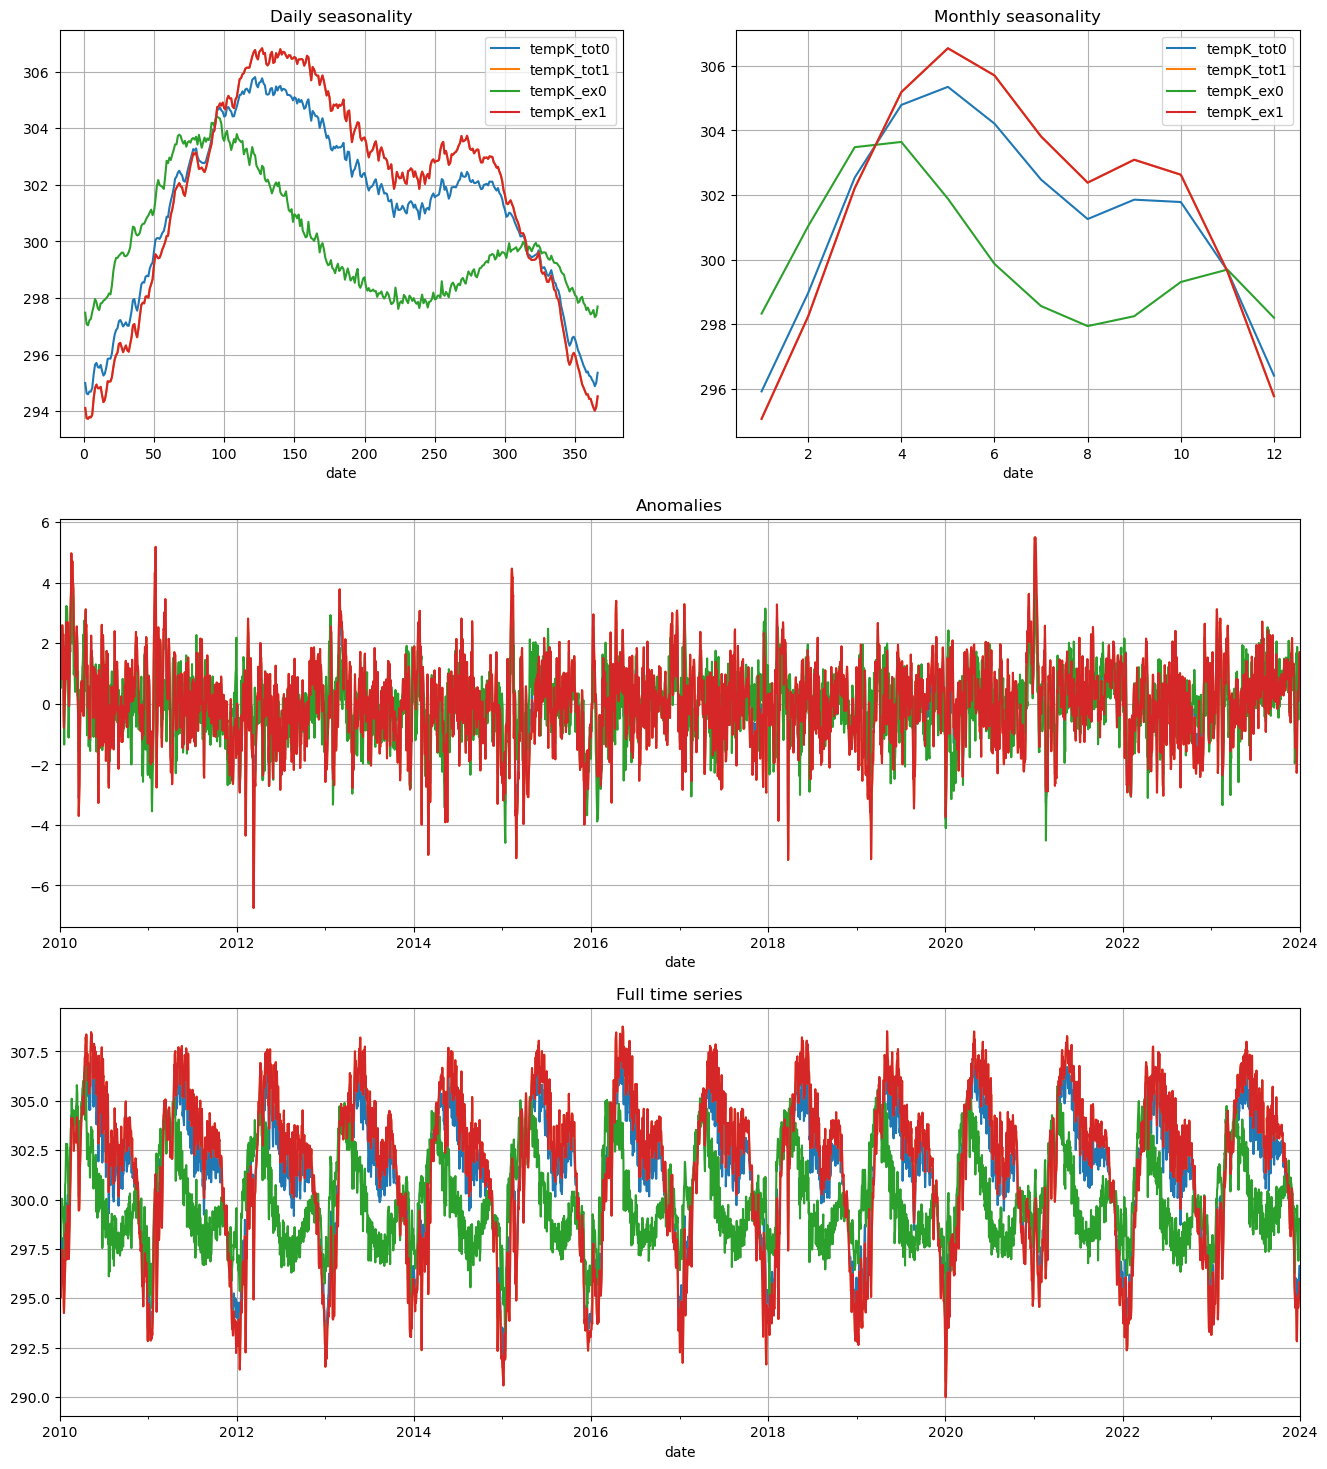

In [13]:
calc_seasonality(full_df[tempK_cols])
output_name = f'tempK_overlays.png'
plt.savefig(save_fp / output_name)
plt.show()

In [8]:
full_df['Q'].value_counts()

Q
-999.000     186
 2642.000     52
 2950.000     40
 3302.000     35
 2611.200     32
            ... 
 3530.272      1
 3697.120      1
 3765.760      1
 3793.568      1
 3273.000      1
Name: count, Length: 1990, dtype: int64

In [7]:
full_df.describe()

,SW_area,SW_flag,Q,tempK_tot0,precipm_tot0,tempK_tot1,precipm_tot1,tempK_ex0,precipm_ex0,tempK_ex1,precipm_ex1
count,1827.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000
mean,1501.060186,0.357255,6512.936432,301.272919,0.764630,301.699677,0.410318,300.008118,0.362325,301.699677,0.410318
std,126.413104,0.479238,6134.760990,3.196139,1.017755,3.909513,0.629924,2.264854,0.500697,3.909513,0.629924
min,1208.402945,0.000000,-999.000000,290.784180,0.000000,289.995697,0.000000,292.929321,0.000000,289.995697,0.000000
25%,1389.439885,0.000000,2626.600000,299.423553,0.007262,299.147980,0.000849,298.309662,0.000861,299.147980,0.000849
50%,1521.306298,0.000000,3385.800000,301.753448,0.293859,302.630447,0.121668,299.546051,0.130979,302.630447,0.121668
75%,1598.787128,1.000000,9072.000000,303.600471,1.215921,304.498993,0.597274,301.621407,0.575207,304.498993,0.597274
max,1782.059091,1.000000,31692.000000,307.858002,6.450814,308.756104,5.420394,306.804260,3.862393,308.756104,5.420394
